## Train a CNN on MNIST using self-supervised learning 

In [1]:
import numpy as np 
import torch, os, pickle, torchvision 
# import torchvision.transforms.v2 as transforms 
from torchvision import transforms 
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
resultsPath = os.path.join('results', f'7_CNN_self_supervised')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [3]:
## defining hyperparameters 
learning_rate = 1e-2
batch_train = 64
batch_test = 1000 
n_epochs = 100
log_intervals = 100 

random_seed = 1
torch.manual_seed(random_seed)

if torch.cuda.is_available():
    device = 'cuda'
    print('GPU available')
else:
    device = 'cpu'
    print('only cpu available')

GPU available


In [4]:
## defining dataloader for training set 
data_train = torchvision.datasets.MNIST(
    root='data',
    download=False,
    train=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.1307,),
            std=(0.3081,)
        )
    ])
)
dataloader_train = torch.utils.data.DataLoader(data_train, batch_size=batch_train)

In [5]:
## defining dataloader for testing set 
data_test = torchvision.datasets.MNIST(
    root='data',
    download=False,
    train=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.1307,),
            std=(0.3081,)
        )
    ])
)
dataloader_test = torch.utils.data.DataLoader(data_test, batch_size=batch_test)

In [6]:
## visualizing example data 
example_data, example_label = next(iter(dataloader_train)) 
print(len(example_data))
print(len(example_label))

64
64


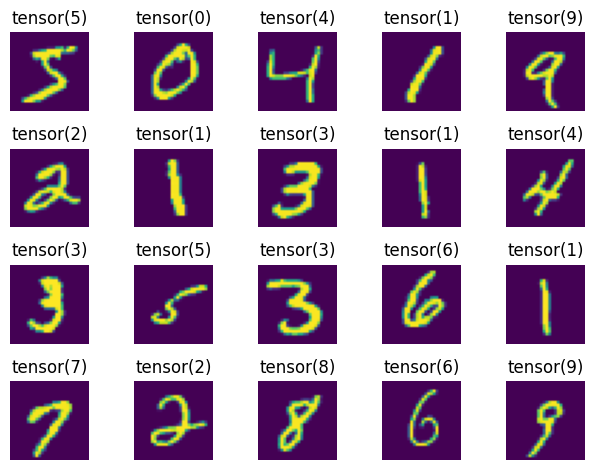

In [7]:
plt.figure()

for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(example_data[i].squeeze())
    plt.axis('off')
    plt.title(example_label[i])

plt.tight_layout() 

In [8]:
example_data.shape 

torch.Size([64, 1, 28, 28])

In [9]:
example_data_rotated = transforms.functional.rotate(example_data, angle=30, fill=-0.4242) 

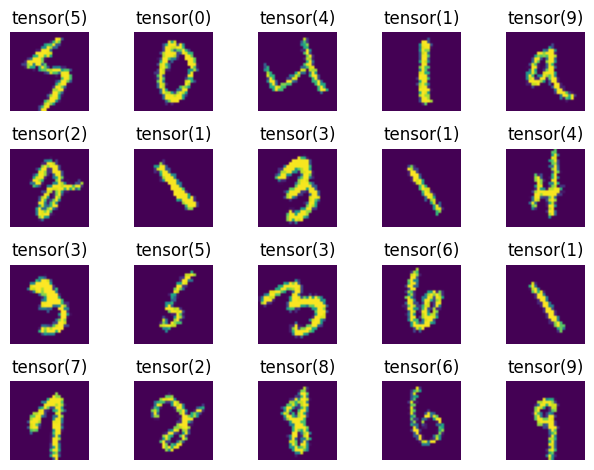

In [10]:
plt.figure()

for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(example_data_rotated[i].squeeze())
    plt.axis('off')
    plt.title(example_label[i])

plt.tight_layout() 

In [11]:
rotations = np.arange(0, 360, 30)

In [12]:
angles_random = np.random.choice(rotations, len(example_data), replace=True) 
angles_random 

array([240, 210,  30, 180, 330, 150, 300,  60,  60, 270, 180, 330,   0,
       240,  90,  30, 210,   0, 240, 300,  30,   0,  90,  30, 210,  60,
        60,  30, 330, 300, 210,   0,   0, 210, 120, 180, 180,  30,  30,
       180, 120, 120, 330, 270, 240, 120,  90, 300,  30, 240, 150, 150,
       300, 300, 300, 120, 300,   0, 120,  30, 150,  90,  90,  30])

In [13]:
for i in np.arange(len(example_data)):
    example_data[i] = transforms.functional.rotate(example_data[i], angle=int(angles_random[i]), fill=-0.4242) 

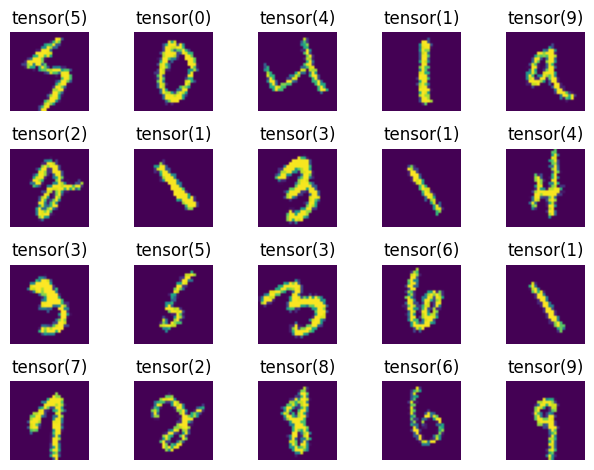

In [14]:
plt.figure()

for i in np.arange(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(example_data_rotated[i].squeeze())
    plt.axis('off')
    plt.title(example_label[i])

plt.tight_layout() 

In [15]:
import torch.nn as nn 
import torch.nn.functional as F 

In [16]:
class CNN_simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=20, kernel_size=3, stride=1, padding=0)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels = 20, out_channels=25, kernel_size=3, stride=1, padding=1) 
        self.maxpool2 = nn.MaxPool2d(kernel_size=3) 
        # original data:  1 x 28 x 28 
        # after conv1:    20 x 26 x 26
        # after maxpool1: 20 x 13 x 13
        # after conv2:    25 x 13 x 13 
        # after maxpool2: 25 x 4 x 4
        self.dense = nn.Linear(in_features=25*4*4, out_features=len(rotations), bias=True)

    def forward(self, x):
        output = F.relu(self.conv1(x)) 
        output = self.maxpool1(output)
        output = F.relu(self.conv2(output))
        output = self.maxpool2(output) 
        output = self.dense(output.reshape(output.shape[0], -1))
        output = F.log_softmax(output)

        return output 

In [17]:
cnn_simple = CNN_simple().to(device)
print(cnn_simple) 

CNN_simple(
  (conv1): Conv2d(1, 20, kernel_size=(3, 3), stride=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (dense): Linear(in_features=400, out_features=12, bias=True)
)


In [18]:
example_output = cnn_simple(example_data_rotated.to(device))

/tmp/ipykernel_2147006/2828149283.py:21: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  output = F.log_softmax(output)


In [19]:
example_output.mean(axis=0)

tensor([-2.2351, -2.5307, -2.2517, -2.5461, -2.4081, -2.3381, -2.5568, -2.6422,
        -2.8517, -2.6659, -2.7074, -2.3415], device='cuda:0',
       grad_fn=<MeanBackward1>)

In [20]:
optimizer = torch.optim.SGD(params=cnn_simple.parameters(), lr=learning_rate)

train_losses = []
test_losses = [] 
train_steps = [] 
test_steps = [len(dataloader_train.dataset)*i for i in np.arange(n_epochs+1)]

In [21]:
def train(epoch):
    cnn_simple.train()

    for batch_id, (data, label) in enumerate(dataloader_train):
        # first randomly rotate data images
        random_indx = np.random.choice(len(rotations), len(data), replace=True)
        random_angles = rotations[random_indx]
        random_angles = list(map(int, random_angles))
        for i in np.arange(len(data)):
            data[i] = transforms.functional.rotate(data[i], angle=random_angles[i], fill=-0.4242)

        data = data.to(device)
        optimizer.zero_grad() 
        output = cnn_simple(data) 
        loss = F.nll_loss(output, torch.tensor(random_indx).to(device))
        loss.backward()
        optimizer.step()

        if batch_id % log_intervals == 0:
            train_losses.append(loss.item()) 
            train_steps.append(batch_id * len(data) + epoch * len(dataloader_train.dataset)) 
            print(f'Training loss: epoch {epoch}, {batch_id * len(data)} / {len(dataloader_train.dataset)}, loss: {train_losses[-1]}')  

In [22]:
def test():
    cnn_simple.eval() 
    test_loss = 0 

    with torch.no_grad():
        for data, label in dataloader_test:
            # first randomly rotate data images 
            random_indx = np.random.choice(len(rotations), len(data), replace=True)
            random_angles = rotations[random_indx]
            random_angles = list(map(int, random_angles)) 
            for i in np.arange(len(data)):
                data[i] = transforms.functional.rotate(data[i], angle=random_angles[i], fill=-0.4242) 

            data = data.to(device)
            output = cnn_simple(data) 
            loss = F.nll_loss(output, torch.tensor(random_indx).to(device))
            test_loss += loss.item() 
        
        test_loss /= len(dataloader_test) 
        test_losses.append(test_loss) 

    print(f'Test loss: {test_loss}') 

In [23]:
len(dataloader_test.dataset) 

10000

In [ ]:
test()

for epoch in np.arange(1, n_epochs+1):
    train(epoch)
    test() 

/tmp/ipykernel_2147006/2828149283.py:21: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  output = F.log_softmax(output)


Test loss: 2.492542839050293
Training loss: epoch 1, 0 / 60000, loss: 2.5219473838806152
Training loss: epoch 1, 6400 / 60000, loss: 1.9882912635803223
Training loss: epoch 1, 12800 / 60000, loss: 1.591132640838623
Training loss: epoch 1, 19200 / 60000, loss: 1.3418335914611816
Training loss: epoch 1, 25600 / 60000, loss: 1.3261761665344238
Training loss: epoch 1, 32000 / 60000, loss: 1.0575615167617798
Training loss: epoch 1, 38400 / 60000, loss: 1.2546241283416748
Training loss: epoch 1, 44800 / 60000, loss: 1.1066913604736328
Training loss: epoch 1, 51200 / 60000, loss: 1.2645360231399536


In [ ]:
plt.figure()

plt.plot(train_steps, train_losses)
plt.plot(test_steps, test_losses)
plt.legend(['train', 'test'])

In [ ]:
# saving currently trained model state
torch.save(cnn_simple.state_dict(), os.path.join(resultsPath, 'cnn_simple.pth'))
torch.save(optimizer.state_dict(), os.path.join(resultsPath, 'optimizer.pth'))

In [ ]:
# remove the current dense layer, which is used to predict rotation angle
# create a new dense layer to predict accuracy. freeze the trained parameters 
for param in cnn_simple.parameters():
    param.require_grads = False 
cnn_simple.dense = nn.Linear(in_features=25*4*4, out_features=10, bias=True)

In [ ]:
cnn_simple = cnn_simple.to(device)

In [ ]:
len(dataloader_train.dataset)

In [ ]:
# training the last layer on limied amount of data 
dataloader_fine_tune_train = torch.utils.data.DataLoader(torch.utils.data.Subset(data_train, np.arange(2000)), batch_size=4, shuffle=True)
dataloader_fine_tune_test = torch.utils.data.DataLoader(torch.utils.data.Subset(data_test, np.arange(2000)), batch_size=5, shuffle=True) 

In [ ]:
len(dataloader_fine_tune_test)

In [ ]:
n_epochs = 100
optimizer = torch.optim.SGD(params=cnn_simple.parameters(), lr=learning_rate)

In [ ]:
train_losses = []
test_losses = [] 
train_steps = [] 
test_steps = [len(dataloader_fine_tune_train.dataset)*i for i in np.arange(n_epochs+1)]
accuracies = [] 

In [ ]:
def train(epoch):
    cnn_simple.train()

    for batch_id, (data, label) in enumerate(dataloader_fine_tune_train):
        data, label = data.to(device), label.to(device)        
        optimizer.zero_grad() 
        output = cnn_simple(data) 
        loss = F.nll_loss(output, label)
        loss.backward()
        optimizer.step()

        if batch_id % log_intervals == 0:
            train_losses.append(loss.item()) 
            train_steps.append(batch_id * len(data) + epoch * len(dataloader_fine_tune_train.dataset)) 
            print(f'Training loss: epoch {epoch}, {batch_id * len(data)} / {len(dataloader_fine_tune_train.dataset)}, loss: {train_losses[-1]}')  

In [ ]:
def test():
    cnn_simple.eval() 
    test_loss = 0 
    pred_correct = 0 

    with torch.no_grad():
        for data, label in dataloader_fine_tune_test:
            data, label = data.to(device), label.to(device)            
            output = cnn_simple(data) 
            loss = F.nll_loss(output, label)
            test_loss += loss.item() 
            pred_label = torch.argmax(output) 
            pred_correct += torch.sum(pred_label == label).detach().cpu()
        
        test_loss /= len(dataloader_fine_tune_test) 
        test_losses.append(test_loss) 
        accuracies.append(pred_correct/len(dataloader_fine_tune_test.dataset))

    print(f'Test loss: {test_loss}, accuracy: {accuracies[-1]}') 

In [ ]:
test()

for epoch in np.arange(1, n_epochs+1):
    train(epoch)
    test()

In [ ]:
plt.figure()

plt.plot(train_steps, train_losses)
plt.plot(test_steps, test_losses)
plt.legend(['train', 'test'])

In [ ]:
plt.figure()

plt.plot(test_steps, accuracies)
plt.legend('accuracy')